# Optimal control without GRAPE — gradient-free schedule optimization

Tutorial notebook: use `SchedulerModel`/`SchedulerTrainer`
(`src/schedule_utils.py`) — the DERIVATIVE-FREE optimal-control path, no
analytic gradient, no GRAPE — to beat the linear-ramp baseline on this
project's frustrated Ising ring at a $\tau$ short enough that linear
annealing visibly struggles.

**When to reach for this instead of `SparseGRAPEModel`/`SparseGRAPETrainer`:**
a quick sanity check on whether a given ansatz/$\tau$/parameter-count combo
can even reach a good energy before investing in GRAPE, a schedule type
GRAPE doesn't (yet) implement, or a cheap starting point to warm-start a
later GRAPE run (same `initial_state` required both places for that to be
valid — see `schedule_utils.py`'s module docstring).

See `LinearQA_Magic_Entanglement_tutorial.ipynb` for the companion linear-
ramp-only tutorial (same Hamiltonians, same sector projection) this
notebook's baseline comparison is drawn from.


## 0. Setup

In [ ]:
import sys, os

REPO_ROOT = os.path.abspath(".")
sys.path.insert(0, REPO_ROOT)

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import expm_multiply, eigsh

from src.annealing_utils import get_driver_hamiltonian, get_longitudinal_hamiltonian
from src.utils import Z2SymmetricSector
from src.schedule_utils import SchedulerModel, SchedulerTrainer

np.set_printoptions(precision=4, suppress=True)

## 1. Ising ring, same sector projection

Identical setup to the linear-QA tutorial — $N=7$ antiferro ising ring, Z2 `sign=+1` sector projection for both Hamiltonians
and the initial state. See `ManyBodyQutip_tutorial.ipynb` for why this
projection is necessary and why it must be the *correct*
(`Z2SymmetricSector`) one, not the naive `Sector` truncation.


In [ ]:
n = 7
jij = np.roll(np.eye(n), 1, axis=1) + np.roll(np.eye(n), -1, axis=1)

H_driver = get_driver_hamiltonian(n)
H_target = get_longitudinal_hamiltonian(jij)

PS = Z2SymmetricSector(nqubits=n, sign=+1)
H_driver_s = PS.project(H_driver).astype(complex)
H_target_s = PS.project(H_target).astype(complex)

psi_init_full = np.ones(2**n, dtype=complex) / np.sqrt(2**n)
psi_init_s = PS.project(psi_init_full)

evals_gs_deg, evecs_gs_deg = eigsh(H_target_s, which="SA", k=10)
order = np.argsort(evals_gs_deg)
evals_gs_deg, evecs_gs_deg = evals_gs_deg[order], evecs_gs_deg[:, order]
gs_mask = evals_gs_deg < evals_gs_deg[0] + 1e-6
gs_energy, evecs_gs_manifold = evals_gs_deg[0], evecs_gs_deg[:, gs_mask]
print(f"GS energy: {gs_energy:.4f}  (degeneracy {gs_mask.sum()} -- frustration)")

Z2SymmetricSector: 64 states out of 128 (sign=+1)
GS energy: -5.0000  (degeneracy 7 -- frustration)


## 2. The linear-ramp baseline, at a SHORT $\tau$

We deliberately pick $\tau=4$ — much shorter than the $\tau=20$ used in the
linear-QA tutorial — specifically because the linear ramp performs
noticeably worse here, which is exactly the regime where investing in an
optimized schedule pays off.


In [ ]:
tau = 4.0
nsteps = 40
tgrid = np.linspace(0, tau, nsteps)
dt = tgrid[1] - tgrid[0]

psi = psi_init_s.copy()
for t in tgrid:
    Ht = (1 - t / tau) * H_driver_s + (t / tau) * H_target_s
    psi = expm_multiply(-1j * dt * Ht, psi)
energy_linear = (psi.conj() @ H_target_s @ psi).real
pop_linear = float(np.sum(np.abs(evecs_gs_manifold.conj().T @ psi) ** 2))

print(
    f"linear ramp,  tau={tau}: final energy = {energy_linear:.4f}"
    f"  (GS = {gs_energy:.4f}, population in GS manifold = {pop_linear:.4f})"
)

linear ramp,  tau=4.0: final energy = -4.7826  (GS = -5.0000, population in GS manifold = 0.9149)


## 3. Gradient-free optimal control: `SchedulerModel` + `SchedulerTrainer`

We use the `'LZS'` ansatz (`M=2` plateaus &rarr; 7 parameters: 5 segment
durations + 2 plateau heights — see `sparse_grape_method.py`'s LZS
walkthrough for the full parametrization, identical here minus the
analytic Jacobian) at the SAME $\tau=4$, same `nsteps`, same `initial_state`
as the linear baseline above.

`SchedulerModel.forward()` has no analytic gradient, so `SchedulerTrainer`
uses Nelder-Mead (derivative-free simplex search — see its docstring for
why). Nelder-Mead from a single random start can land in different local
minima on this non-convex landscape, so — standard practice for
derivative-free local optimizers — we run a handful of random restarts and
keep the best. `np.random.seed(...)` per restart makes this notebook's
output reproducible.


In [ ]:
n_restarts = 3
maxiter = 200
M = 2  # number of LZS plateaus

best_result = None
for restart in range(n_restarts):
    np.random.seed(restart)
    model = SchedulerModel(
        initial_state=psi_init_s,
        target_hamiltonian=H_target_s,
        initial_hamiltonian=H_driver_s,
        reference_hamiltonian=H_target_s,
        tf=tau,
        number_of_parameters=M,
        nsteps=nsteps,
        type="LZS",
        seed=restart,
        random=True,
    )
    trainer = SchedulerTrainer(
        model, maxiter=maxiter, method="Nelder-Mead", verbose=False
    )
    result = trainer.run()
    print(
        f"  restart {restart}: final energy = {result['energy']:.4f}"
        f"  (nfev={result['n_evals']}, success={result['success']})"
    )
    if best_result is None or result["energy"] < best_result["energy"]:
        best_result = result
        best_model = model

pop_opt = float(np.sum(np.abs(evecs_gs_manifold.conj().T @ best_result["psi"]) ** 2))
print(
    f"\nbest optimal-control energy: {best_result['energy']:.4f}"
    f"  (GS = {gs_energy:.4f}, population in GS manifold = {pop_opt:.4f})"
)
print(
    f"linear ramp for comparison : {energy_linear:.4f}  (population = {pop_linear:.4f})"
)

  restart 0: final energy = -4.9612  (nfev=333, success=False)


  restart 1: final energy = -4.1930  (nfev=311, success=False)


  restart 2: final energy = -4.3276  (nfev=330, success=False)

best optimal-control energy: -4.9612  (GS = -5.0000, population in GS manifold = 0.9580)
linear ramp for comparison : -4.7826  (population = 0.9149)


## 4. What the optimized schedule looks like

`get_lzs_waypoints()` decodes the current parameters into the segment
boundary times and plateau heights actually used — overlay that on the
$h_{\text{driver}}(t)$/$h_{\text{target}}(t)$ curves themselves.


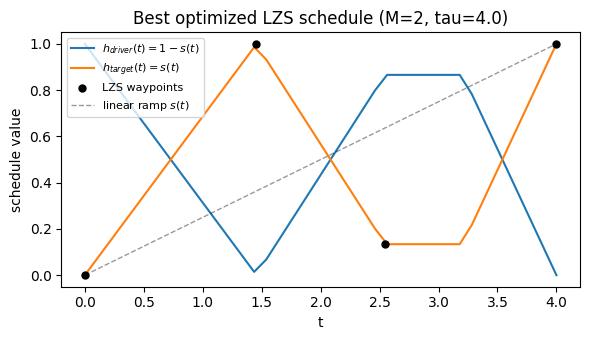

In [ ]:
h_driver_opt, h_target_opt = best_model.get_driving()
t_bounds, s_way = best_model.get_lzs_waypoints()

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(tgrid, h_driver_opt, label="$h_{driver}(t) = 1-s(t)$")
ax.plot(tgrid, h_target_opt, label="$h_{target}(t) = s(t)$")
# t_bounds has 2M+2 entries (segment boundaries); s_way has M+2
# entries (one value per waypoint -- each interior waypoint is held
# constant across a whole plateau, so pick its START time to plot it).
waypoint_times = np.concatenate(([t_bounds[0]], t_bounds[1:-1:2], [t_bounds[-1]]))
ax.plot(waypoint_times, s_way, "ko", ms=5, label="LZS waypoints")
ax.plot([0, tau], [0, 1], "k--", lw=1, alpha=0.4, label="linear ramp $s(t)$")
ax.set_xlabel("t")
ax.set_ylabel("schedule value")
ax.set_title(f"Best optimized LZS schedule (M={M}, tau={tau})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Optimization convergence

`SchedulerTrainer` records `history_energy` per accepted Nelder-Mead
iteration (via `model.callback`) — plotted here for the winning restart
only (the others aren't retained by `SchedulerModel`, since `verbose=False`
was used above to keep the run quiet; rerun a single restart with
`verbose=True` if you want its live history too).


restart seed=0: 199 accepted iterations, final energy -4.9612


/tmp/repo/src/schedule_utils.py:331: RuntimeWarning: Maximum number of iterations has been exceeded.
  res = minimize(


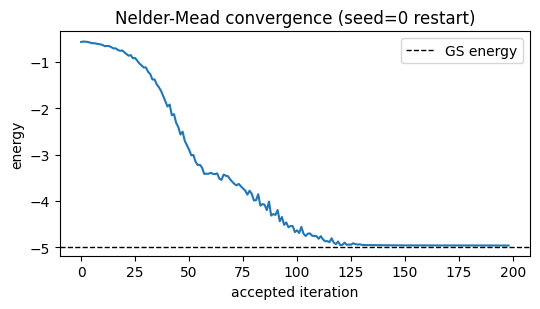

In [ ]:
# Rerun the seed=0 restart once more, this time letting SchedulerTrainer's
# own verbose=True path populate model.history via its callback -- gives us
# the per-accepted-iteration energy trace for that restart. Output is
# captured/suppressed below since verbose=True prints one line per
# iteration (useful live, noisy in a saved notebook).
import io, contextlib

np.random.seed(0)
history_model = SchedulerModel(
    initial_state=psi_init_s,
    target_hamiltonian=H_target_s,
    initial_hamiltonian=H_driver_s,
    reference_hamiltonian=H_target_s,
    tf=tau,
    number_of_parameters=M,
    nsteps=nsteps,
    type="LZS",
    seed=0,
    random=True,
)
history_trainer = SchedulerTrainer(
    history_model, maxiter=maxiter, method="Nelder-Mead", verbose=True
)
with contextlib.redirect_stdout(io.StringIO()):
    history_result = history_trainer.run()

print(
    f"restart seed=0: {len(history_model.history)} accepted iterations, "
    f"final energy {history_result['energy']:.4f}"
)

plt.figure(figsize=(5.5, 3.2))
plt.plot(history_model.history)
plt.axhline(gs_energy, color="k", ls="--", lw=1, label="GS energy")
plt.xlabel("accepted iteration")
plt.ylabel("energy")
plt.title("Nelder-Mead convergence (seed=0 restart)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Takeaways

- At the same short $\tau=4$ where the linear ramp leaves noticeable
  population outside the (degenerate) ground manifold, a handful of
  Nelder-Mead restarts on a 7-parameter LZS ansatz recovers most of the
  gap to the ground state — with **no analytic gradient at all**.
- This came at a real cost: many more Hamiltonian propagations than a
  single GRAPE run would need (`n_restarts * nfev` full forward passes vs.
  one gradient-informed L-BFGS-B run) — the right tool when GRAPE isn't
  available/needed, not a free lunch.
- Multiple restarts were necessary here because Nelder-Mead on this
  landscape is seed-sensitive (see the per-restart printout in §3 — some
  restarts do noticeably worse than others). Don't trust a single
  gradient-free run's result without at least a couple of restarts.
- The SAME `initial_state` (`psi_init_s`) was used here as would be passed
  to `SparseGRAPEModel` — so this optimized schedule's parameters are a
  legitimate warm-start candidate for a follow-up GRAPE refinement (mind
  the Fourier-scaling caveat in `schedule_utils.py` if you switch ansatz
  types when doing that).
